# Sigmoid vs ReLU Activation Functions: The Inference Cost of Losing Geometric Context

A deep neural network can be understood as a geometric system, where each layer reshapes the input space to form increasingly complex decision boundaries. For this to work effectively, layers must preserve meaningful spatial information — particularly how far a data point lies from these boundaries — since this distance enables deeper layers to build rich, non-linear representations.

Sigmoid disrupts this process by compressing all inputs into a narrow range between 0 and 1. As values move away from decision boundaries, they become indistinguishable, causing a loss of geometric context across layers. This leads to weaker representations and limits the effectiveness of depth.

ReLU, on the other hand, preserves magnitude for positive inputs, allowing distance information to flow through the network. This enables deeper models to remain expressive without requiring excessive width or compute.

In this article, we focus on this forward-pass behavior — analyzing how Sigmoid and ReLU differ in signal propagation and representation geometry using a two-moons experiment, and what that means for inference efficiency and scalability.

## Setting up the dependencies

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
plt.rcParams.update({
    "font.family":        "monospace",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.facecolor":   "white",
    "axes.facecolor":     "#f7f7f7",
    "axes.grid":          True,
    "grid.color":         "#e0e0e0",
    "grid.linewidth":     0.6,
})

T = {
    "bg":      "white",
    "panel":   "#f7f7f7",
    "sig":     "#e05c5c",
    "relu":    "#3a7bd5",
    "c0":      "#f4a261",
    "c1":      "#2a9d8f",
    "text":    "#1a1a1a",
    "muted":   "#666666",
}

## Creating the dataset
To study the effect of activation functions in a controlled setting, we first generate a synthetic dataset using scikit-learn’s make_moons. This creates a non-linear, two-class problem where simple linear boundaries fail, making it ideal for testing how well neural networks learn complex decision surfaces.

We add a small amount of noise to make the task more realistic, then standardize the features using StandardScaler so both dimensions are on the same scale — ensuring stable training. The dataset is then split into training and test sets to evaluate generalization.

Finally, we visualize the data distribution. This plot serves as the baseline geometry that both Sigmoid and ReLU networks will attempt to model, allowing us to later compare how each activation function transforms this space across layers.

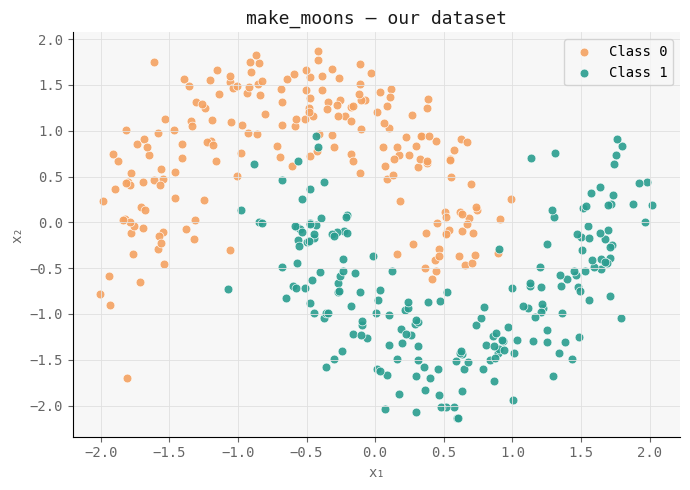

In [ ]:
X, y = make_moons(n_samples=400, noise=0.18, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(T["bg"])
ax.set_facecolor(T["panel"])
ax.scatter(X[y == 0, 0], X[y == 0, 1], c=T["c0"], s=40,
           edgecolors="white", linewidths=0.5, label="Class 0", alpha=0.9)
ax.scatter(X[y == 1, 0], X[y == 1, 1], c=T["c1"], s=40,
           edgecolors="white", linewidths=0.5, label="Class 1", alpha=0.9)
ax.set_title("make_moons — our dataset", color=T["text"], fontsize=13)
ax.set_xlabel("x₁", color=T["muted"]); ax.set_ylabel("x₂", color=T["muted"])
ax.tick_params(colors=T["muted"]); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("moons_dataset.png", dpi=140, bbox_inches="tight")
plt.show()

## Creating the Network
Next, we implement a small, controlled neural network to isolate the effect of activation functions. The goal here is not to build a highly optimized model, but to create a clean experimental setup where Sigmoid and ReLU can be compared under identical conditions.

We define both activation functions (Sigmoid and ReLU) along with their derivatives, and use binary cross-entropy as the loss since this is a binary classification task. The TwoLayerNet class represents a simple 3-layer feedforward network (2 hidden layers + output), where the only configurable component is the activation function.

A key detail is the initialization strategy: we use He initialization for ReLU and Xavier initialization for Sigmoid, ensuring that each network starts in a fair and stable regime based on its activation dynamics.

The forward pass computes activations layer by layer, while the backward pass performs standard gradient descent updates. Importantly, we also include diagnostic methods like get_hidden and get_z_trace, which allow us to inspect how signals evolve across layers — this is crucial for analyzing how much geometric information is preserved or lost.

By keeping architecture, data, and training setup constant, this implementation ensures that any difference in performance or internal representations can be directly attributed to the activation function itself — setting the stage for a clear comparison of their impact on signal propagation and expressiveness.

In [ ]:
def sigmoid(z):      return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def sigmoid_d(a):    return a * (1 - a)
def relu(z):         return np.maximum(0, z)
def relu_d(z):       return (z > 0).astype(float)
def bce(y, yhat):    return -np.mean(y * np.log(yhat + 1e-9) + (1 - y) * np.log(1 - yhat + 1e-9))

class TwoLayerNet:
    def __init__(self, activation="relu", seed=0):
        np.random.seed(seed)
        self.act_name = activation
        self.act  = relu    if activation == "relu" else sigmoid
        self.dact = relu_d  if activation == "relu" else sigmoid_d

        # He init for ReLU, Xavier for Sigmoid
        scale = lambda fan_in: np.sqrt(2 / fan_in) if activation == "relu" else np.sqrt(1 / fan_in)
        self.W1 = np.random.randn(2, 8)  * scale(2)
        self.b1 = np.zeros((1, 8))
        self.W2 = np.random.randn(8, 8)  * scale(8)
        self.b2 = np.zeros((1, 8))
        self.W3 = np.random.randn(8, 1)  * scale(8)
        self.b3 = np.zeros((1, 1))
        self.loss_history = []

    def forward(self, X, store=False):
        z1 = X  @ self.W1 + self.b1;  a1 = self.act(z1)
        z2 = a1 @ self.W2 + self.b2;  a2 = self.act(z2)
        z3 = a2 @ self.W3 + self.b3;  out = sigmoid(z3)
        if store:
            self._cache = (X, z1, a1, z2, a2, z3, out)
        return out

    def backward(self, lr=0.05):
        X, z1, a1, z2, a2, z3, out = self._cache
        n = X.shape[0]

        dout = (out - self.y_cache) / n
        dW3 = a2.T @ dout;  db3 = dout.sum(axis=0, keepdims=True)
        da2 = dout @ self.W3.T
        dz2 = da2 * (self.dact(z2) if self.act_name == "relu" else self.dact(a2))
        dW2 = a1.T @ dz2;  db2 = dz2.sum(axis=0, keepdims=True)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * (self.dact(z1) if self.act_name == "relu" else self.dact(a1))
        dW1 = X.T  @ dz1;  db1 = dz1.sum(axis=0, keepdims=True)

        for p, g in [(self.W3,dW3),(self.b3,db3),(self.W2,dW2),
                     (self.b2,db2),(self.W1,dW1),(self.b1,db1)]:
            p -= lr * g

    def train_step(self, X, y, lr=0.05):
        self.y_cache = y.reshape(-1, 1)
        out = self.forward(X, store=True)
        loss = bce(self.y_cache, out)
        self.backward(lr)
        return loss

    def get_hidden(self, X, layer=1):
        """Return post-activation values for layer 1 or 2."""
        z1 = X @ self.W1 + self.b1;  a1 = self.act(z1)
        if layer == 1: return a1
        z2 = a1 @ self.W2 + self.b2; return self.act(z2)

    def get_z_trace(self, x_single):
        """Return pre-activation magnitudes per layer for ONE sample."""
        z1 = x_single @ self.W1 + self.b1
        a1 = self.act(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = self.act(z2)
        z3 = a2 @ self.W3 + self.b3
        return [np.abs(z1).mean(), np.abs(a1).mean(),
                np.abs(z2).mean(), np.abs(a2).mean(),
                np.abs(z3).mean()]

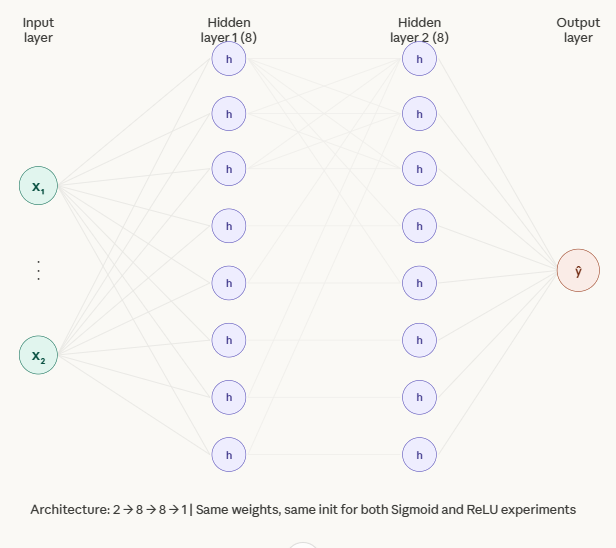

## Training the Networks
Now we train both networks under identical conditions to ensure a fair comparison. We initialize two models — one using Sigmoid and the other using ReLU — with the same random seed so they start from equivalent weight configurations.

The training loop runs for 800 epochs using mini-batch gradient descent. In each epoch, we shuffle the training data, split it into batches, and update both networks in parallel. This setup guarantees that the only variable changing between the two runs is the activation function.

We also track the loss after every epoch and log it at regular intervals. This allows us to observe how each network evolves over time — not just in terms of convergence speed, but whether it continues improving or plateaus.

This step is critical because it establishes the first signal of divergence: if both models start identically but behave differently during training, that difference must come from how each activation function propagates and preserves information through the network.

In [ ]:
EPOCHS = 800
LR     = 0.05
BATCH  = 64

net_sig  = TwoLayerNet("sigmoid", seed=42)
net_relu = TwoLayerNet("relu",    seed=42)

for epoch in range(EPOCHS):
    idx = np.random.permutation(len(X_train))
    for net in [net_sig, net_relu]:
        epoch_loss = []
        for i in range(0, len(idx), BATCH):
            b = idx[i:i+BATCH]
            loss = net.train_step(X_train[b], y_train[b], LR)
            epoch_loss.append(loss)
        net.loss_history.append(np.mean(epoch_loss))

    if (epoch + 1) % 200 == 0:
        ls = net_sig.loss_history[-1]
        lr = net_relu.loss_history[-1]
        print(f"  Epoch {epoch+1:4d} | Sigmoid loss: {ls:.4f} | ReLU loss: {lr:.4f}")

print("\n✅ Training complete.")

  Epoch  200 | Sigmoid loss: 0.3589 | ReLU loss: 0.1549
  Epoch  400 | Sigmoid loss: 0.2875 | ReLU loss: 0.0566
  Epoch  600 | Sigmoid loss: 0.2871 | ReLU loss: 0.0450
  Epoch  800 | Sigmoid loss: 0.2822 | ReLU loss: 0.0353

✅ Training complete.


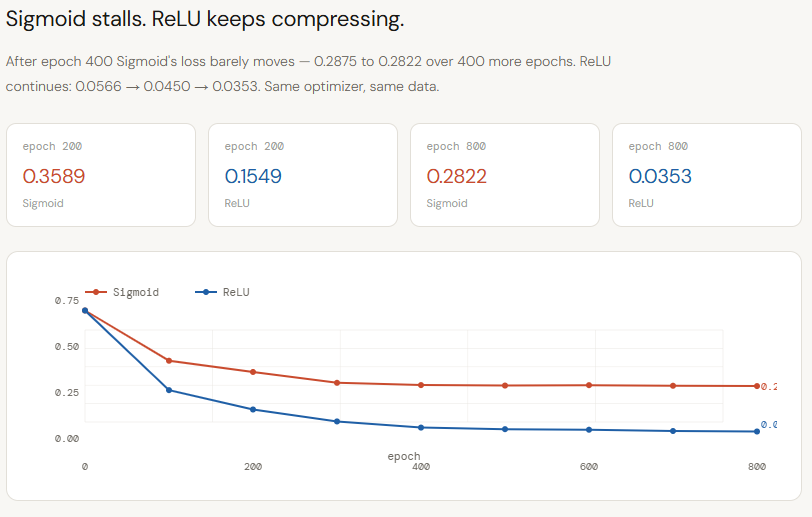

## Training Loss Curve
The loss curves make the divergence between Sigmoid and ReLU very clear. Both networks start from the same initialization and are trained under identical conditions, yet their learning trajectories quickly separate. Sigmoid improves initially but plateaus around ~0.28 by epoch 400, showing almost no progress afterward — a sign that the network has exhausted the useful signal it can extract.

ReLU, in contrast, continues to steadily reduce loss throughout training, dropping from ~0.15 to ~0.03 by epoch 800. This isn’t just faster convergence; it reflects a deeper issue: Sigmoid’s compression is limiting the flow of meaningful information, causing the model to stall, while ReLU preserves that signal, allowing the network to keep refining its decision boundary.

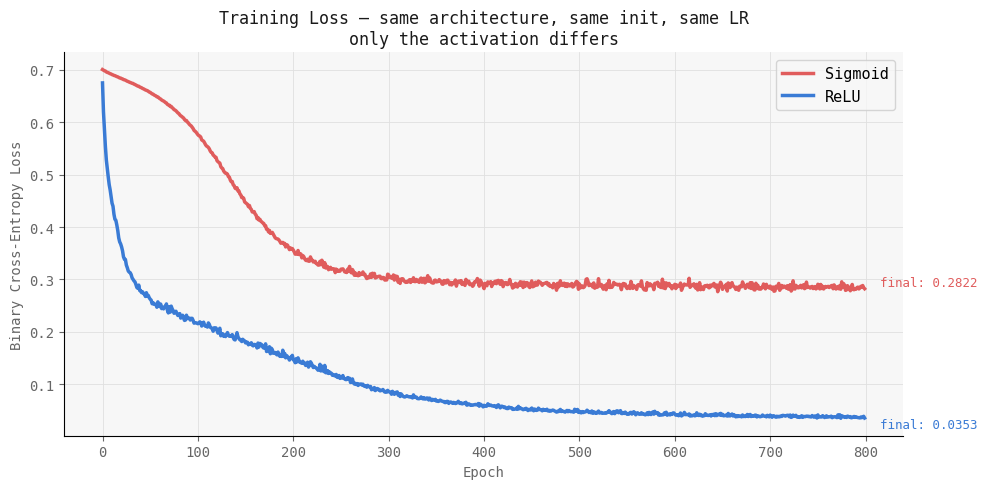

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(T["bg"])
ax.set_facecolor(T["panel"])

ax.plot(net_sig.loss_history,  color=T["sig"],  lw=2.5, label="Sigmoid")
ax.plot(net_relu.loss_history, color=T["relu"], lw=2.5, label="ReLU")

ax.set_xlabel("Epoch", color=T["muted"])
ax.set_ylabel("Binary Cross-Entropy Loss", color=T["muted"])
ax.set_title("Training Loss — same architecture, same init, same LR\nonly the activation differs",
             color=T["text"], fontsize=12)
ax.legend(fontsize=11)
ax.tick_params(colors=T["muted"])

# Annotate final losses
for net, color, va in [(net_sig, T["sig"], "bottom"), (net_relu, T["relu"], "top")]:
    final = net.loss_history[-1]
    ax.annotate(f"  final: {final:.4f}", xy=(EPOCHS-1, final),
                color=color, fontsize=9, va=va)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=140, bbox_inches="tight")
plt.show()

## Decision Boundary Plots
The decision boundary visualization makes the difference even more tangible. The Sigmoid network learns a nearly linear boundary, failing to capture the curved structure of the two-moons dataset, which results in lower accuracy (~79%). This is a direct consequence of its compressed internal representations — the network simply doesn’t have enough geometric signal to construct a complex boundary.

In contrast, the ReLU network learns a highly non-linear, well-adapted boundary that closely follows the data distribution, achieving much higher accuracy (~96%). Because ReLU preserves magnitude across layers, it enables the network to progressively bend and refine the decision surface, turning depth into actual expressive power rather than wasted capacity.

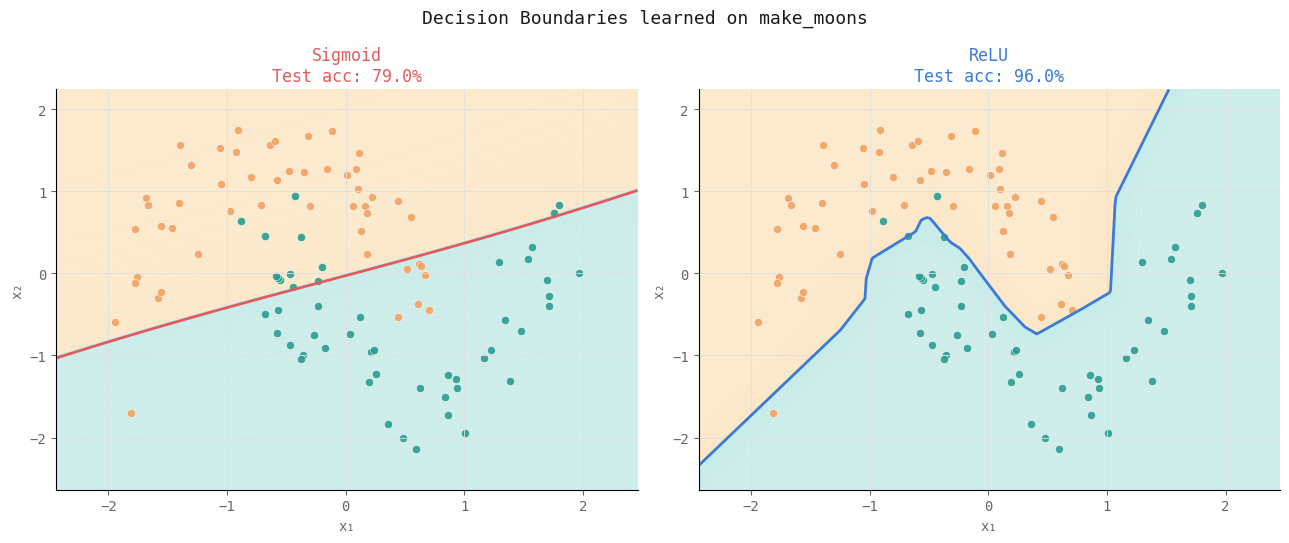

In [ ]:
def plot_boundary(ax, net, X, y, title, color):
    h = 0.025
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = net.forward(grid).reshape(xx.shape)

    # Soft shading
    cmap_bg = ListedColormap(["#fde8c8", "#c8ece9"])
    ax.contourf(xx, yy, Z, levels=50, cmap=cmap_bg, alpha=0.85)
    ax.contour(xx, yy, Z, levels=[0.5], colors=[color], linewidths=2)

    ax.scatter(X[y==0, 0], X[y==0, 1], c=T["c0"], s=35,
               edgecolors="white", linewidths=0.4, alpha=0.9)
    ax.scatter(X[y==1, 0], X[y==1, 1], c=T["c1"], s=35,
               edgecolors="white", linewidths=0.4, alpha=0.9)

    acc = ((net.forward(X) >= 0.5).ravel() == y).mean()
    ax.set_title(f"{title}\nTest acc: {acc:.1%}", color=color, fontsize=12)
    ax.set_xlabel("x₁", color=T["muted"]); ax.set_ylabel("x₂", color=T["muted"])
    ax.tick_params(colors=T["muted"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor(T["bg"])
fig.suptitle("Decision Boundaries learned on make_moons",
             fontsize=13, color=T["text"])

plot_boundary(axes[0], net_sig,  X_test, y_test, "Sigmoid", T["sig"])
plot_boundary(axes[1], net_relu, X_test, y_test, "ReLU",    T["relu"])

plt.tight_layout()
plt.savefig("decision_boundaries.png", dpi=140, bbox_inches="tight")
plt.show()

## Layer-by-Layer Signal Trace
This chart tracks how the signal evolves across layers for a point far from the decision boundary — and it clearly shows where Sigmoid fails. Both networks start with similar pre-activation magnitude at the first layer (~2.0), but Sigmoid immediately compresses it to ~0.3, while ReLU retains a higher value. As we move deeper, Sigmoid continues to squash the signal into a narrow band (0.5–0.6), effectively erasing meaningful differences. ReLU, on the other hand, preserves and amplifies magnitude, with the final layer reaching values as high as 9–20.

This means the output neuron in the ReLU network is making decisions based on a strong, well-separated signal, while the Sigmoid network is forced to classify using a weak, compressed one. The key takeaway is that ReLU preserves distance from the decision boundary across layers, allowing that information to compound, whereas Sigmoid progressively destroys it.

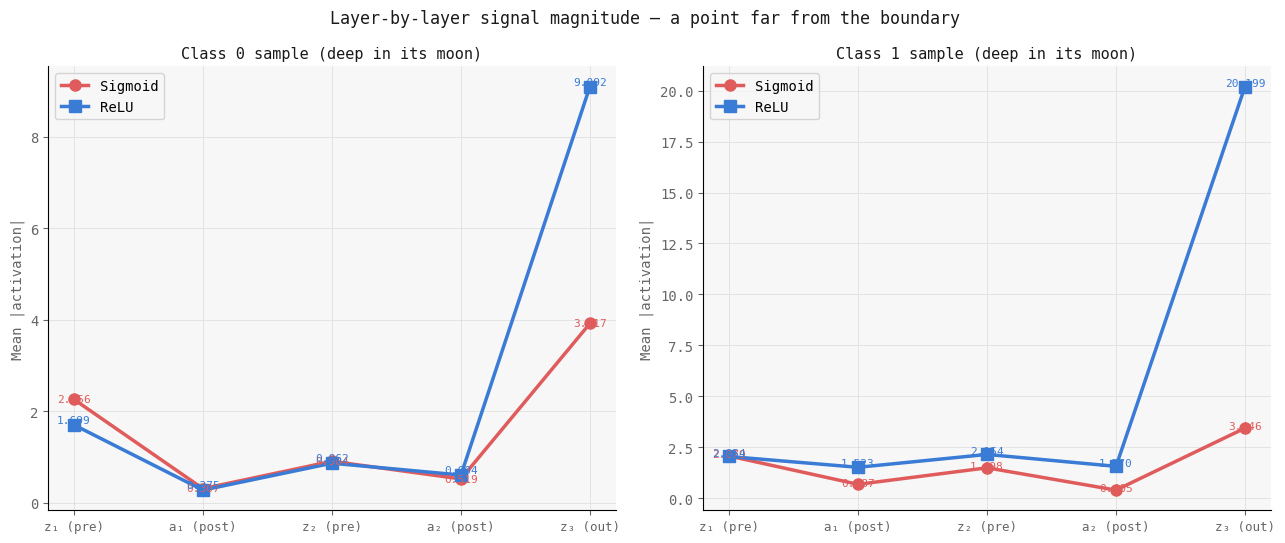

In [ ]:
far_class0 = X_train[y_train == 0][np.argmax(
    np.linalg.norm(X_train[y_train == 0] - [-1.2, -0.3], axis=1)
)]
far_class1 = X_train[y_train == 1][np.argmax(
    np.linalg.norm(X_train[y_train == 1] - [1.2, 0.3], axis=1)
)]

stage_labels = ["z₁ (pre)", "a₁ (post)", "z₂ (pre)", "a₂ (post)", "z₃ (out)"]
x_pos = np.arange(len(stage_labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor(T["bg"])
fig.suptitle("Layer-by-layer signal magnitude — a point far from the boundary",
             fontsize=12, color=T["text"])

for ax, sample, title in zip(
    axes,
    [far_class0, far_class1],
    ["Class 0 sample (deep in its moon)", "Class 1 sample (deep in its moon)"]
):
    ax.set_facecolor(T["panel"])
    sig_trace  = net_sig.get_z_trace(sample.reshape(1, -1))
    relu_trace = net_relu.get_z_trace(sample.reshape(1, -1))

    ax.plot(x_pos, sig_trace,  "o-", color=T["sig"],  lw=2.5, markersize=8, label="Sigmoid")
    ax.plot(x_pos, relu_trace, "s-", color=T["relu"], lw=2.5, markersize=8, label="ReLU")

    for i, (s, r) in enumerate(zip(sig_trace, relu_trace)):
        ax.text(i, s - 0.06, f"{s:.3f}", ha="center", fontsize=8, color=T["sig"])
        ax.text(i, r + 0.04, f"{r:.3f}", ha="center", fontsize=8, color=T["relu"])

    ax.set_xticks(x_pos); ax.set_xticklabels(stage_labels, color=T["muted"], fontsize=9)
    ax.set_ylabel("Mean |activation|", color=T["muted"])
    ax.set_title(title, color=T["text"], fontsize=11)
    ax.tick_params(colors=T["muted"]); ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("signal_trace.png", dpi=140, bbox_inches="tight")
plt.show()

## Hidden Space Scatter
This is the most important visualization because it directly exposes how each network uses (or fails to use) depth. In the Sigmoid network (left), both classes collapse into a tight, overlapping region — a diagonal smear where points are heavily entangled. The standard deviation actually decreases from layer 1 (0.26) to layer 2 (0.19), meaning the representation is becoming less expressive with depth. Each layer is compressing the signal further, stripping away the spatial structure needed to separate the classes.

ReLU shows the opposite behavior. In layer 1, while some neurons are inactive (the “dead zone”), the active ones already spread across a wider range (1.15 std), indicating preserved variation. By layer 2, this expands even further (1.67 std), and the classes become clearly separable — one is pushed to high activation ranges while the other remains near zero. At this point, the output layer’s job is trivial.

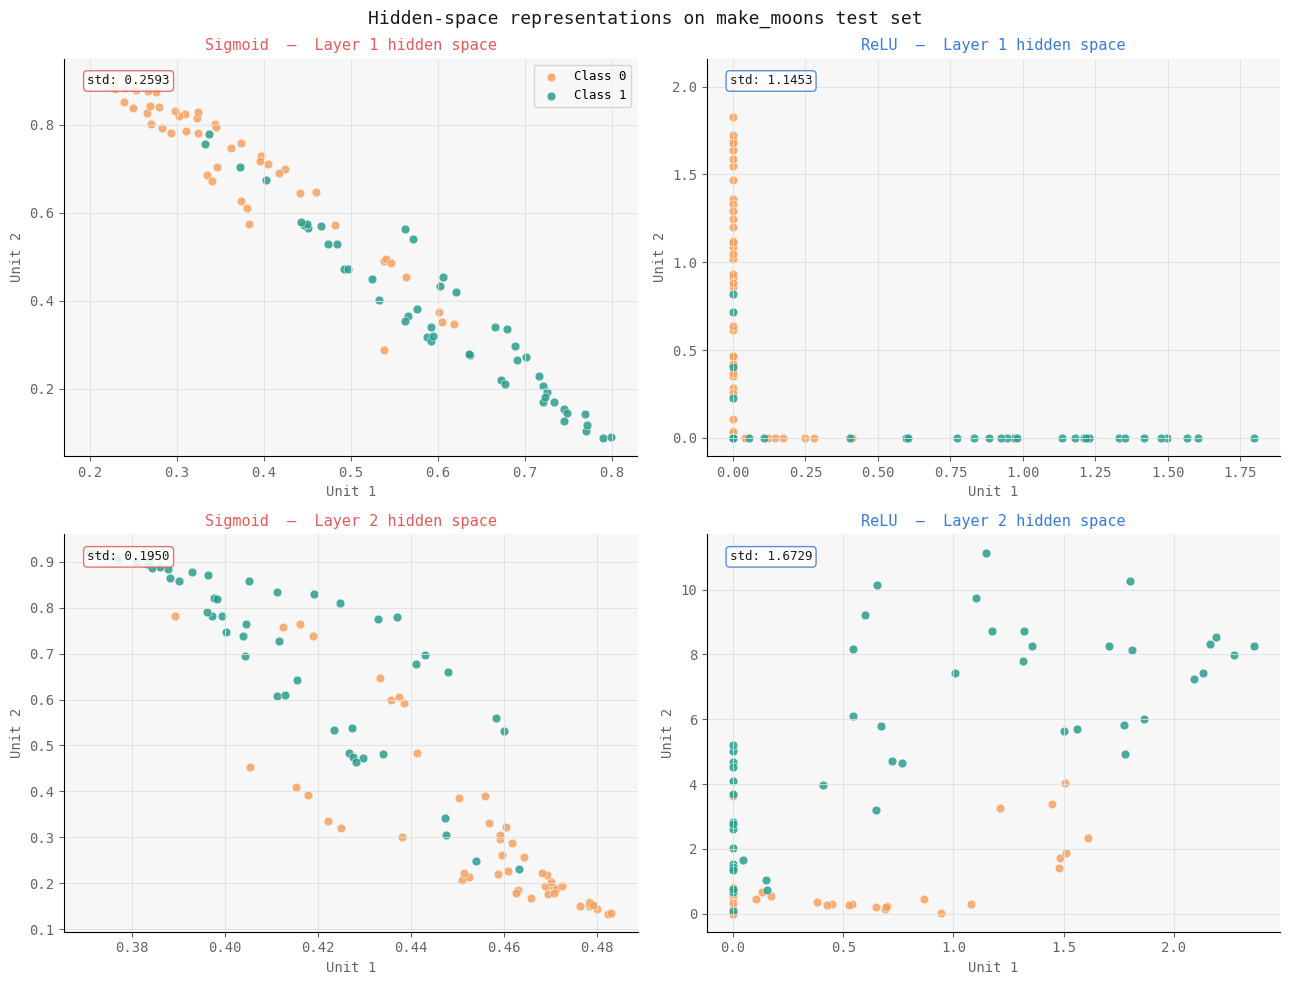

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.patch.set_facecolor(T["bg"])
fig.suptitle("Hidden-space representations on make_moons test set",
             fontsize=13, color=T["text"])

for col, (net, color, name) in enumerate([
    (net_sig,  T["sig"],  "Sigmoid"),
    (net_relu, T["relu"], "ReLU"),
]):
    for row, layer in enumerate([1, 2]):
        ax = axes[row][col]
        ax.set_facecolor(T["panel"])
        H = net.get_hidden(X_test, layer=layer)

        ax.scatter(H[y_test==0, 0], H[y_test==0, 1], c=T["c0"], s=40,
                   edgecolors="white", linewidths=0.4, alpha=0.85, label="Class 0")
        ax.scatter(H[y_test==1, 0], H[y_test==1, 1], c=T["c1"], s=40,
                   edgecolors="white", linewidths=0.4, alpha=0.85, label="Class 1")

        spread = H.std()
        ax.text(0.04, 0.96, f"std: {spread:.4f}",
                transform=ax.transAxes, fontsize=9, va="top",
                color=T["text"],
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.85))

        ax.set_title(f"{name}  —  Layer {layer} hidden space",
                     color=color, fontsize=11)
        ax.set_xlabel(f"Unit 1", color=T["muted"])
        ax.set_ylabel(f"Unit 2", color=T["muted"])
        ax.tick_params(colors=T["muted"])
        if row == 0 and col == 0: ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("hidden_space.png", dpi=140, bbox_inches="tight")
plt.show()

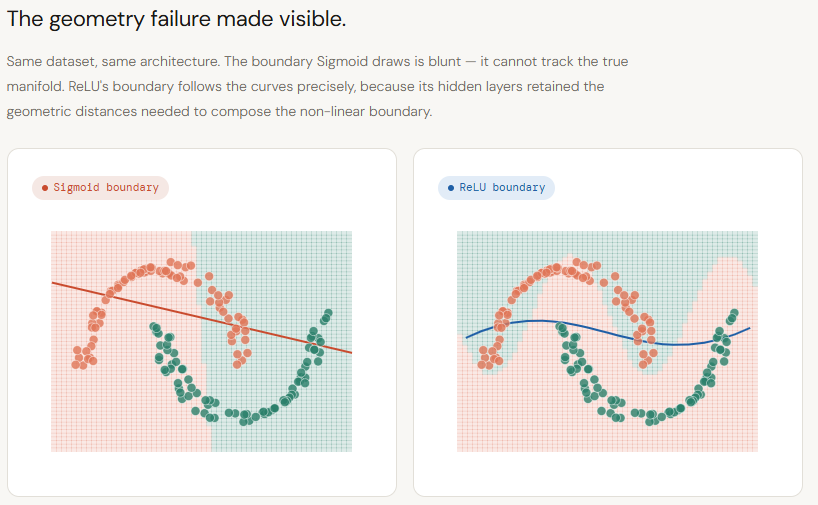